In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


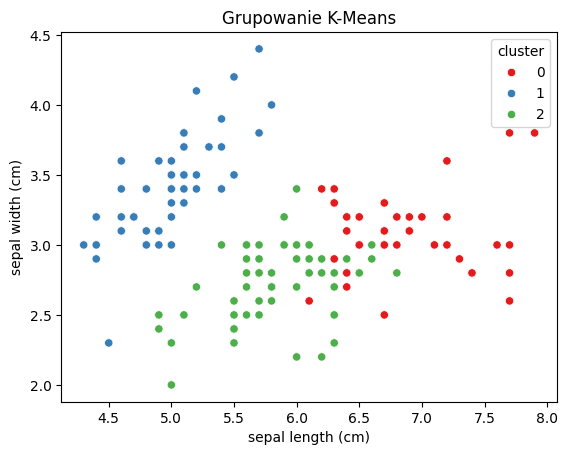

cluster   0   1   2
species            
0         0  50   0
1         3   0  47
2        36   0  14


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
df['cluster'] = kmeans.labels_
sns.scatterplot(x=df[feature_names[0]], y=df[feature_names[1]], hue=df['cluster'], palette='Set1')
plt.title('Grupowanie K-Means')
plt.show()
print(pd.crosstab(df['species'], df['cluster']))

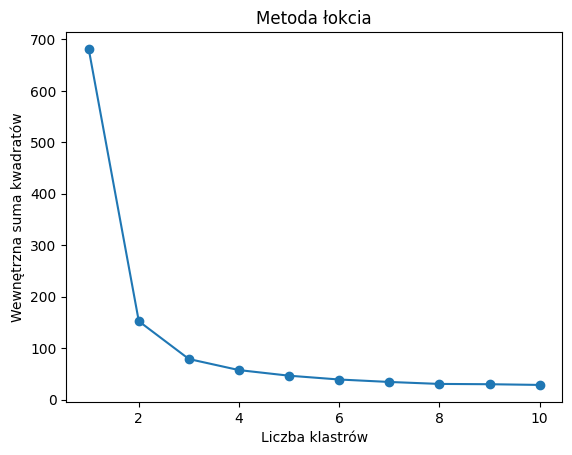

In [6]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Liczba klastrów')
plt.ylabel('Wewnętrzna suma kwadratów')
plt.title('Metoda łokcia')
plt.show()

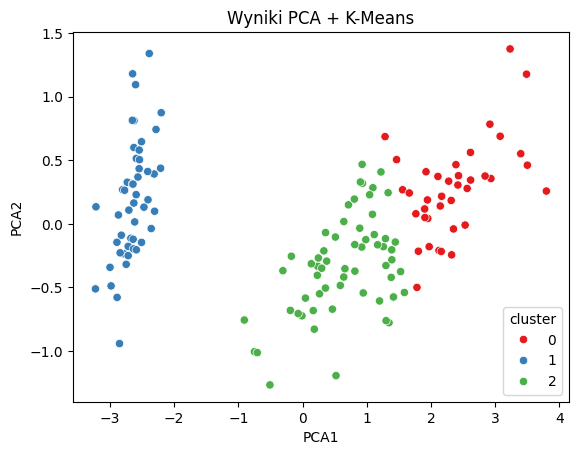

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
sns.scatterplot(x=df['PCA1'], y=df['PCA2'], hue=df['cluster'], palette='Set1')
plt.title("Wyniki PCA + K-Means")
plt.show()